# Trabalho de EST1 - G13

**Análise comparativa de idades de esposas e maridos**

In [1]:
%matplotlib inline

# Importar bibliotecas
import pandas as pd
import numpy as np
from scipy.stats import shapiro, probplot, mannwhitneyu, norm
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

# Define o formato de saída para SVG
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
%config InlineBackend.figure_format = 'svg'

import warnings
warnings.filterwarnings('ignore')

# ── Constantes visuais ──────────────────────────────────────────────────────
ROTULOS = ['Esposas', 'Maridos']
CORES   = ['pink', 'lightblue']
FIG_SIZE = (10, 5)

## Carregamento e validação dos dados

In [2]:
# Carrega a base salarios
salarios = pd.read_csv("salarios.csv")

# Dataset com apenas idades de esposas e maridos
df = salarios[["age", "husage"]].copy()

print(f"Total de registros: {len(df):,}")
print(f"\nValores ausentes por coluna:")
print(df.isna().sum().to_string())
print(f"\nResumo estatístico básico:")
display(df.describe().round(2))

Total de registros: 5,634

Valores ausentes por coluna:
age       0
husage    0

Resumo estatístico básico:


,age,husage
count,5634.00,5634.00
mean,39.43,42.45
std,9.99,11.23
min,18.00,19.00
25%,31.00,34.00
50%,39.00,41.00
75%,47.00,50.00
max,59.00,86.00


---
## 1. Gráficos e Tabelas

### 1.1 Box-plot comparativo de idades

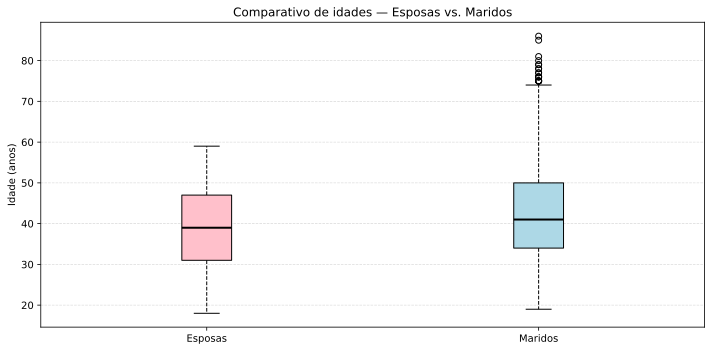

Esposas    → IQR=16.0  limite superior=71.0  outliers=0
Maridos    → IQR=16.0  limite superior=74.0  outliers=21


In [3]:
def calcular_outliers(serie: pd.Series) -> tuple[float, float, int]:
    """Retorna (limite_superior, IQR, contagem_outliers) para uma série."""
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = Q3 - Q1
    lim_sup = Q3 + 1.5 * iqr
    n_outliers = (serie > lim_sup).sum()
    return lim_sup, iqr, n_outliers


fig, ax = plt.subplots(figsize=FIG_SIZE)

bplot = ax.boxplot(
    df.to_numpy(),
    patch_artist=True,
    tick_labels=ROTULOS,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linestyle='--'),
)

for patch, color in zip(bplot['boxes'], CORES):
    patch.set_facecolor(color)

ax.set_ylabel('Idade (anos)')
ax.set_title('Comparativo de idades — Esposas vs. Maridos')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, axis='y', color='gray', linestyle='--', linewidth=0.7, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Resumo de outliers ──────────────────────────────────────────────────────
for col, rotulo in zip(['age', 'husage'], ROTULOS):
    lim, iqr, n = calcular_outliers(df[col])
    print(f"{rotulo:10s} → IQR={iqr:.1f}  limite superior={lim:.1f}  outliers={n}")

### 1.2 Histogramas de distribuição de idades

Número de classes (Regra de Sturges): k = 1 + log₂(5634) ≈ 14


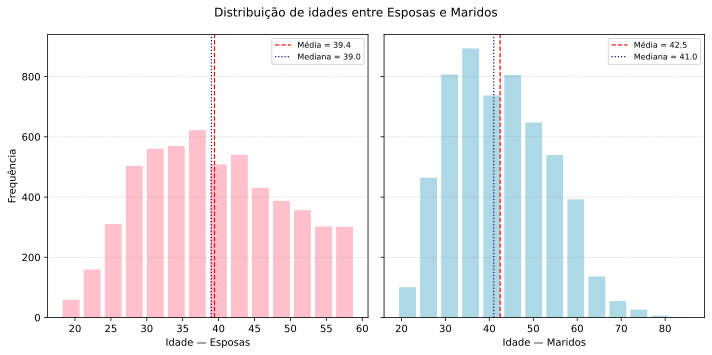

In [4]:
n = len(df)
k = int(np.round(np.ceil(1 + np.log2(n))))  # Regra de Sturges (mesmo critério do numpy)
print(f"Número de classes (Regra de Sturges): k = 1 + log₂({n}) ≈ {k}")

fig, axs = plt.subplots(1, 2, sharey=True, figsize=FIG_SIZE)

for ax, col, rotulo, cor in zip(axs, ['age', 'husage'], ROTULOS, CORES):
    ax.hist(df[col], bins='sturges', color=cor, rwidth=0.85, edgecolor='white')
    ax.set_xlabel(f'Idade — {rotulo}')
    ax.set_facecolor('white')
    ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.7, alpha=0.3)
    # Linha vertical da média
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2,
               label=f'Média = {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='navy', linestyle=':', linewidth=1.2,
               label=f'Mediana = {df[col].median():.1f}')
    ax.legend(fontsize=8)

axs[0].set_ylabel('Frequência')
fig.suptitle('Distribuição de idades entre Esposas e Maridos')

plt.tight_layout()
plt.show()

### 1.3 Tabelas de frequência

In [5]:
def tabela_frequencia(serie: pd.Series, k: int, nome: str) -> pd.DataFrame:
    """Gera tabela de distribuição de frequência com colunas absolutas,
    relativas e acumuladas para uma série numérica."""
    bins = pd.cut(serie, bins=k, include_lowest=True)
    freq_abs = bins.value_counts().sort_index()
    freq_rel = bins.value_counts(normalize=True).sort_index() * 100

    tabela = pd.DataFrame({
        'Freq. Absoluta': freq_abs,
        'Freq. Relativa (%)': freq_rel.round(2),
    })
    tabela['Freq. Acumulada'] = tabela['Freq. Absoluta'].cumsum()
    tabela['Freq. Rel. Acumulada (%)'] = tabela['Freq. Relativa (%)'].cumsum().round(2)

    print(f"\nTabela de Distribuição de Frequência — {nome}:")
    display(tabela)
    return tabela


tabela_esp = tabela_frequencia(df['age'],    k, 'Esposas')
tabela_mar = tabela_frequencia(df['husage'], k, 'Maridos')


Tabela de Distribuição de Frequência — Esposas:


,Freq. Absoluta,Freq. Relativa (%),Freq. Acumulada,Freq. Rel. Acumulada (%)
age,,,,
"(17.958, 20.929]",61,1.08,61,1.08
"(20.929, 23.857]",161,2.86,222,3.94
"(23.857, 26.786]",312,5.54,534,9.48
"(26.786, 29.714]",505,8.96,1039,18.44
"(29.714, 32.643]",562,9.98,1601,28.42
"(32.643, 35.571]",571,10.13,2172,38.55
"(35.571, 38.5]",624,11.08,2796,49.63
"(38.5, 41.429]",510,9.05,3306,58.68
"(41.429, 44.357]",542,9.62,3848,68.30



Tabela de Distribuição de Frequência — Maridos:


,Freq. Absoluta,Freq. Relativa (%),Freq. Acumulada,Freq. Rel. Acumulada (%)
husage,,,,
"(18.932, 23.786]",102,1.81,102,1.81
"(23.786, 28.571]",466,8.27,568,10.08
"(28.571, 33.357]",809,14.36,1377,24.44
"(33.357, 38.143]",895,15.89,2272,40.33
"(38.143, 42.929]",739,13.12,3011,53.45
"(42.929, 47.714]",807,14.32,3818,67.77
"(47.714, 52.5]",649,11.52,4467,79.29
"(52.5, 57.286]",541,9.60,5008,88.89
"(57.286, 62.071]",394,6.99,5402,95.88


---
## 2. Medidas de posição e dispersão

### 2.1 Tabela comparativa consolidada

In [6]:
def resumo_estatistico(serie: pd.Series) -> dict:
    """Calcula as principais medidas de posição e dispersão."""
    media  = serie.mean()
    std    = serie.std()
    return {
        'Média':                  round(media, 2),
        'Mediana':                round(serie.median(), 2),
        'Moda':                   round(serie.mode()[0], 2),
        'Variância':              round(serie.var(), 2),
        'Desvio Padrão':          round(std, 2),
        'Coef. de Variação (%)':  round(std / media * 100, 2),
    }


resumo = pd.DataFrame({
    'Esposas': resumo_estatistico(df['age']),
    'Maridos': resumo_estatistico(df['husage']),
})

# Coluna de diferença percentual (maridos em relação a esposas)
resumo['Diferença (%)'] = ((resumo['Maridos'] / resumo['Esposas']) - 1).mul(100).round(2)

print("Resumo comparativo de posição e dispersão:")
display(resumo)

Resumo comparativo de posição e dispersão:


,Esposas,Maridos,Diferença (%)
Média,39.43,42.45,7.66
Mediana,39.00,41.00,5.13
Moda,37.00,44.00,18.92
Variância,99.75,126.07,26.39
Desvio Padrão,9.99,11.23,12.41
Coef. de Variação (%),25.33,26.45,4.42


**Interpretação:** Os maridos apresentam, em geral, idades maiores do que as esposas em todas as medidas de posição. O coeficiente de variação similar entre os grupos (~25–27%) indica dispersão relativa parecida, embora os maridos tenham variância absoluta maior — reflexo da maior amplitude etária (outliers acima de 60 anos observados no boxplot).

---
## 3. Testes paramétricos ou não paramétricos

### 3.1 Teste de normalidade (Shapiro-Wilk)

A decisão entre teste paramétrico (t de Student não pareado) e não paramétrico (Mann-Whitney U) depende da normalidade das amostras.

In [7]:
x1 = df['age'].to_numpy()    # idade das esposas
x2 = df['husage'].to_numpy() # idade dos maridos

stat1, pvalue1 = shapiro(x1)
stat2, pvalue2 = shapiro(x2)

ALPHA = 0.05

print("Teste de Shapiro-Wilk (H₀: distribuição normal)")
print(f"  {'Grupo':<10} {'Estatística W':>15} {'p-valor':>12} {'Normal?':>10}")
print(f"  {'-'*52}")
for rotulo, stat, pval in [(ROTULOS[0], stat1, pvalue1), (ROTULOS[1], stat2, pvalue2)]:
    normal = pval >= ALPHA
    print(f"  {rotulo:<10} {stat:>15.4f} {pval:>12.2e} {'✓ Sim' if normal else '✗ Não':>10}")

print(f"\nConclusão: como p-valor < {ALPHA} em ambos os grupos, rejeitamos H₀ de normalidade.")
print("→ Utilizaremos o teste não paramétrico de Mann-Whitney U.")

Teste de Shapiro-Wilk (H₀: distribuição normal)
  Grupo        Estatística W      p-valor    Normal?
  ----------------------------------------------------
  Esposas             0.9764     1.40e-29      ✗ Não
  Maridos             0.9814     1.45e-26      ✗ Não

Conclusão: como p-valor < 0.05 em ambos os grupos, rejeitamos H₀ de normalidade.
→ Utilizaremos o teste não paramétrico de Mann-Whitney U.


### 3.2 Gráficos Q-Q (confirmação visual)

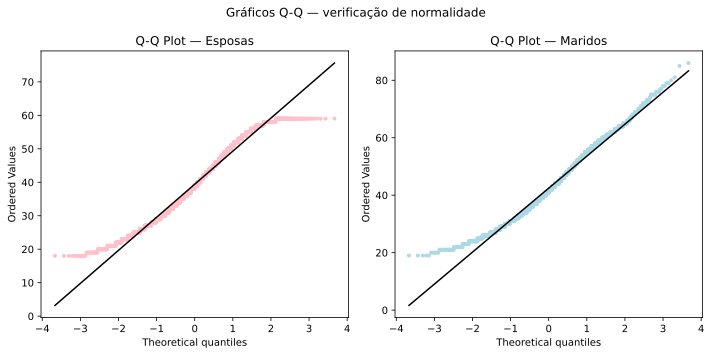

In [8]:
fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

configs = [
    (x1, 'Q-Q Plot — Esposas', 'pink'),
    (x2, 'Q-Q Plot — Maridos', 'lightblue'),
]

for ax, (dados, titulo, cor) in zip(axes, configs):
    probplot(dados, dist='norm', plot=ax)
    ax.set_title(titulo)
    ax.lines[0].set_color(cor)      # pontos
    ax.lines[0].set_markersize(3)
    ax.lines[1].set_color('black')  # linha de referência
    ax.set_facecolor('white')

fig.suptitle('Gráficos Q-Q — verificação de normalidade')
plt.tight_layout()
plt.show()

### 3.3 Teste de Mann-Whitney U

In [9]:
stat_mw, p_mw = mannwhitneyu(x1, x2, alternative='two-sided')

print("Teste de Mann-Whitney U")
print(f"  H₀: as medianas de 'age' e 'husage' são iguais")
print(f"  H₁: as medianas são diferentes (bicaudal)")
print(f"")
print(f"  Estatística U = {stat_mw:.4f}")
print(f"  p-valor       = {p_mw:.4e}")
print(f"")
decisao = 'Rejeita H₀' if p_mw < ALPHA else 'Não rejeita H₀'
print(f"  Decisão (α = {ALPHA}): {decisao}")
if p_mw < ALPHA:
    print("  → Há evidência estatística de que as medianas são diferentes.")

Teste de Mann-Whitney U
  H₀: as medianas de 'age' e 'husage' são iguais
  H₁: as medianas são diferentes (bicaudal)

  Estatística U = 13619912.0000
  p-valor       = 6.9589e-39

  Decisão (α = 0.05): Rejeita H₀
  → Há evidência estatística de que as medianas são diferentes.


### 3.4 Intervalo de confiança — Estimador de Hodges-Lehmann

In [10]:
def hodges_lehmann_ci(
    x: np.ndarray,
    y: np.ndarray,
    alpha: float = 0.05
) -> tuple[float, tuple[float, float]]:
    """
    Calcula o estimador de Hodges-Lehmann e o intervalo de confiança
    para a diferença de localização entre duas amostras independentes.

    Parâmetros
    ----------
    x, y   : arrays das duas amostras
    alpha  : nível de significância (padrão 0.05 → IC 95%)

    Retorna
    -------
    (estimador_HL, (limite_inferior, limite_superior))
    """
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    m, n = len(x), len(y)

    # Todas as diferenças cruzadas xi − yj
    diffs = np.sort([xi - yi for xi in x for yi in y])
    N = m * n

    # Estimador de Hodges-Lehmann
    hl = float(np.median(diffs))

    # Índice k via aproximação normal da distribuição de Mann-Whitney
    mu    = N / 2
    sigma = np.sqrt(m * n * (m + n + 1) / 12)
    z     = norm.ppf(1 - alpha / 2)
    k     = max(1, int(np.floor(mu - z * sigma)) + 1)

    lower = float(diffs[k - 1])
    upper = float(diffs[N - k])

    return hl, (lower, upper)


# x2 − x1 (maridos − esposas) → diferença positiva esperada
hl, (ci_low, ci_high) = hodges_lehmann_ci(x2, x1, alpha=ALPHA)
ic_nivel = int((1 - ALPHA) * 100)

print("Estimador de Hodges-Lehmann (diferença de localização: Maridos − Esposas)")
print(f"  Estimativa pontual : {hl:.2f} anos")
print(f"  IC {ic_nivel}%              : [{ci_low:.2f}, {ci_high:.2f}]")
print()
if ci_low > 0:
    print(f"  O IC não contém zero → confirma diferença significativa.")
    print(f"  Os maridos são, em mediana, {hl:.0f} anos mais velhos que as esposas.")
elif ci_high < 0:
    print(f"  O IC não contém zero → esposas são mais velhas.")
else:
    print(f"  O IC contém zero → diferença não significativa ao nível {ALPHA}.")

Estimador de Hodges-Lehmann (diferença de localização: Maridos − Esposas)
  Estimativa pontual : 3.00 anos
  IC 95%              : [2.00, 3.00]

  O IC não contém zero → confirma diferença significativa.
  Os maridos são, em mediana, 3 anos mais velhos que as esposas.


---
## 4. Conclusões

| Análise | Resultado |
|---|---|
| Normalidade (Shapiro-Wilk) | Ambas as amostras **não** seguem distribuição normal (p < 0,05) |
| Teste escolhido | **Mann-Whitney U** (não paramétrico) |
| Resultado do teste | Rejeita H₀ — medianas são **estatisticamente diferentes** |
| Estimador Hodges-Lehmann | Diferença estimada de **~3 anos** (maridos mais velhos) |
| IC 95% | Não contém zero → diferença **significativa** |

**Conclusão geral:** Os maridos são, em média e mediana, significativamente mais velhos que as esposas (~3 anos de diferença mediana). Essa conclusão é robusta: confirmada visualmente pelos boxplots/histogramas, estatisticamente pelo teste não paramétrico e quantificada pelo intervalo de confiança de Hodges-Lehmann.